In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deepfake-videos-dataset/DeepFake Videos Dataset.csv
/kaggle/input/deepfake-videos-dataset/deepfake/3.mp4
/kaggle/input/deepfake-videos-dataset/deepfake/1.mp4
/kaggle/input/deepfake-videos-dataset/deepfake/4.mp4
/kaggle/input/deepfake-videos-dataset/deepfake/5.mov
/kaggle/input/deepfake-videos-dataset/deepfake/2.mp4
/kaggle/input/deepfake-videos-dataset/video/3.mp4
/kaggle/input/deepfake-videos-dataset/video/1.mp4
/kaggle/input/deepfake-videos-dataset/video/4.mp4
/kaggle/input/deepfake-videos-dataset/video/5.MOV
/kaggle/input/deepfake-videos-dataset/video/2.mp4
/kaggle/input/deepfake-videos-dataset/image/5.jpg
/kaggle/input/deepfake-videos-dataset/image/1.jpg
/kaggle/input/deepfake-videos-dataset/image/2.jpeg
/kaggle/input/deepfake-videos-dataset/image/4.jpg
/kaggle/input/deepfake-videos-dataset/image/3.jpg


In [2]:
# Kaggle notebook skeleton: rPPG-based Deepfake Detection Prototype
# Repository base: rPPG-Toolbox (ubicomplab) as the rPPG extraction backend
# Assumptions:
# - You will attach ~10 sample videos to the Kaggle notebook via "Add data".
# - Those videos will be available at: /kaggle/input/sample-videos/*
# - Kernel has internet so we can `git clone` public repos. If not, upload the repos or required files.
# - This is a prototype: we extract rPPG signals, compute simple features, train a small classifier.


In [3]:
%%bash
set -e

# 1) Clone repo if not already present
if [ ! -d "rPPG-Toolbox" ]; then
    git clone https://github.com/ubicomplab/rPPG-Toolbox.git
else
    echo "rPPG-Toolbox already present; skipping clone."
fi

# 2) Do NOT install the repo's requirements.txt (avoids dlib + big pinned deps)
# If you want to inspect it, you can print it instead:
if [ -f rPPG-Toolbox/requirements.txt ]; then
    echo "Found rPPG-Toolbox/requirements.txt — not installing it to avoid conflicts."
fi

# 3) Install only lightweight extras we actually need for detection/extraction
#    (opencv for video I/O; mediapipe helps face detection/landmarks and is optional)
python -m pip install -q opencv-python-headless mediapipe || true

echo "Clone done. Skipped heavy installs. Only opencv/mediapipe installed."


Found rPPG-Toolbox/requirements.txt — not installing it to avoid conflicts.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.1 MB/s eta 0:00:00
Clone done. Skipped heavy installs. Only opencv/mediapipe installed.


Cloning into 'rPPG-Toolbox'...
Updating files: 100% (327/327), done.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydata-profiling 4.17.0 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is

In [4]:
# ------------------------------
# Cell 2: Imports and config
# ------------------------------
# Paste into a Python code cell

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import joblib

# Paths (adjusted for your provided dataset)
DATASET_ROOT = '/kaggle/input/deepfake-videos-dataset'
VIDEO_INPUT_DIRS = [os.path.join(DATASET_ROOT, 'deepfake'), os.path.join(DATASET_ROOT, 'video')]
RPPG_OUTPUT_DIR = '/kaggle/working/rppg_signals'
os.makedirs(RPPG_OUTPUT_DIR, exist_ok=True)


# Sampling rate assumption for video (adjust per your video frame rate if known)
FS = 30.0

# collect video paths (common video extensions)
video_paths = []
for d in VIDEO_INPUT_DIRS:
    if os.path.isdir(d):
        for ext in ('*.mp4','*.MP4','*.mov','*.MOV','*.avi'):
            video_paths.extend(sorted(glob.glob(os.path.join(d, ext))))
print('Found videos:', len(video_paths))

Found videos: 10


In [5]:
# ------------------------------
# Cell 3: Minimal rPPG extraction function (CHROM method fallback)
# ------------------------------
# We include a small, self-contained CHROM implementation so the notebook works
# even if rPPG-Toolbox functions change. This is a basic extractor: face detection -> ROI -> CHROM.

# NOTE: This is intended for prototype use only. For production, use the rPPG-Toolbox APIs.

import cv2

# Try MediaPipe if available else Haar cascades
USE_MEDIAPIPE = False
try:
    import mediapipe as mp
    mp_face = mp.solutions.face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)
    USE_MEDIAPIPE = True
    print('Using MediaPipe FaceDetection for detection.')
except Exception:
    print('MediaPipe not available — using Haar cascade fallback.')

_haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


def detect_face_bbox(frame):
    # returns (x,y,w,h) or None
    h, w = frame.shape[:2]
    if USE_MEDIAPIPE:
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = mp_face.process(img_rgb)
        if getattr(results, 'detections', None):
            det = results.detections[0].location_data.relative_bounding_box
            x = int(det.xmin * w)
            y = int(det.ymin * h)
            bw = int(det.width * w)
            bh = int(det.height * h)
            x = max(0, x); y = max(0, y)
            bw = min(w-x, max(10, bw)); bh = min(h-y, max(10, bh))
            return (x,y,bw,bh)
    # Haar fallback
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = _haar_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) > 0:
        return faces[0]
    # center crop fallback
    s = min(h, w)
    return (int((w - s) / 2), int((h - s) / 2), s, s)


def extract_roi_mean_colors(video_path, max_frames=None, resize_width=320):
    """Extract per-frame mean RGB from face ROI and return (rgb_array, fps).
    Returns None if no face detected.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError('Cannot open ' + video_path)
    # try to read fps from the video; if unavailable, default to FS global
    fps = cap.get(cv2.CAP_PROP_FPS)
    try:
        fps = float(fps)
        if fps <= 0 or np.isnan(fps):
            fps = FS
    except Exception:
        fps = FS
    rgb_means = []
    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        if max_frames and frame_count > max_frames:
            break
        # optional resize for speed
        h, w = frame.shape[:2]
        if w > resize_width:
            scale = resize_width / w
            frame = cv2.resize(frame, (int(w * scale), int(h * scale)))
        bbox = detect_face_bbox(frame)
        if bbox is None:
            continue
        x, y, bw, bh = bbox
        roi = frame[y:y+bh, x:x+bw]
        if roi.size == 0:
            continue
        # take spatial mean in RGB
        mean_rgb = np.mean(roi.reshape(-1, 3), axis=0)  # BGR order from OpenCV
        mean_rgb = mean_rgb[::-1]  # convert to RGB
        rgb_means.append(mean_rgb)
    cap.release()
    if len(rgb_means) == 0:
        return None, fps
    return np.array(rgb_means), fps

# --- Replace your previous chrom_method with this fixed one ---
from scipy import signal
import numpy as np

def chrom_method(rgb_ts, fs=30.0):
    """
    Corrected CHROM rPPG extraction.
    rgb_ts: (T,3) array in float (0..255)
    fs: sampling frequency (frames per second)
    returns: 1D rPPG signal (length T)
    """
    X = rgb_ts.astype(float)
    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("rgb_ts must be shape (T,3)")
    # Normalize per-channel
    mean = X.mean(axis=0)
    Xn = X / (mean + 1e-8)
    # Correct projection matrix (3 x 2) so Xn @ M -> (T,2)
    M = np.array([[0, -2],
                  [1,  1],
                  [-1, 1]], dtype=float)   # shape (3,2)
    S = np.dot(Xn, M)  # S.shape -> (T,2)
    # combine the two signals (as in CHROM)
    s1 = S[:, 0]
    s2 = S[:, 1]
    std0 = s1.std()
    std1 = s2.std()
    alpha = 0.0 if std1 == 0 else std0 / (std1 + 1e-8)
    chrom = s1 - alpha * s2
    # detrend & bandpass (safe handling)
    chrom = signal.detrend(chrom)
    low = 0.7 / fs
    high = 3.5 / fs
    # clamp band limits
    low = max(low, 1e-4)
    high = min(max(high, low + 1e-4), 0.999)
    try:
        b, a = signal.butter(3, [low, high], btype='band')
        if len(chrom) >= 6:
            chrom = signal.filtfilt(b, a, chrom)
    except Exception:
        # fallback to a simple demeaned signal if filtering fails
        chrom = chrom - np.mean(chrom)
    return chrom


2025-11-09 16:10:46.068382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762704646.302316      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762704646.363813      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using MediaPipe FaceDetection for detection.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1762704659.311103     131 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [6]:
# ------------------------------
# Cell 4: Batch process videos -> save rPPG signals and simple metadata
# ------------------------------
# This will process videos found under the 'deepfake' and 'video' dirs and save rPPG .npy files

import os, glob, numpy as np, pandas as pd
from pathlib import Path

# remove old signals (safe)
old_files = glob.glob(os.path.join(RPPG_OUTPUT_DIR, '*_rppg.npy')) + [os.path.join(RPPG_OUTPUT_DIR,'meta.csv')]
for f in old_files:
    try:
        os.remove(f)
    except Exception:
        pass

records = []
for input_dir in VIDEO_INPUT_DIRS:
    vpaths = sorted(glob.glob(os.path.join(input_dir, '*')))
    for vp in vpaths:
        if not os.path.isfile(vp):
            continue
        base = os.path.splitext(os.path.basename(vp))[0]
        print('Processing', vp)
        try:
            rgb, fps = extract_roi_mean_colors(vp, max_frames=800, resize_width=480)  # allow full ~10s at 30fps
            if rgb is None:
                print('  No face detected — skipping', vp)
                continue
            # ensure rgb shape is (T,3)
            if rgb.ndim != 2 or rgb.shape[1] != 3:
                print('  Unexpected rgb shape', rgb.shape, '— skipping', vp)
                continue
            rppg = chrom_method(rgb, fs=fps if fps>0 else 30.0)
            out_npy = os.path.join(RPPG_OUTPUT_DIR, base + '_rppg.npy')
            np.save(out_npy, rppg)
            parent = os.path.basename(os.path.dirname(vp)).lower()
            label = 1 if 'deepfake' in parent or 'fake' in parent or 'manip' in parent else 0
            records.append({
                'video': base,
                'path': vp,
                'rppg_path': out_npy,
                'frames': int(rgb.shape[0]),
                'fps': float(fps),
                'label': int(label)
            })
            print('  Saved rPPG:', out_npy, 'len=', len(rppg))
        except Exception as e:
            print('  Failed', vp, e)

meta_df = pd.DataFrame(records)
meta_csv = os.path.join(RPPG_OUTPUT_DIR, 'meta.csv')
meta_df.to_csv(meta_csv, index=False)
print('Done. Wrote meta:', meta_csv)
print(meta_df)


Processing /kaggle/input/deepfake-videos-dataset/deepfake/1.mp4


/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Saved rPPG: /kaggle/working/rppg_signals/1_rppg.npy len= 200
Processing /kaggle/input/deepfake-videos-dataset/deepfake/2.mp4
  Saved rPPG: /kaggle/working/rppg_signals/2_rppg.npy len= 135
Processing /kaggle/input/deepfake-videos-dataset/deepfake/3.mp4
  Saved rPPG: /kaggle/working/rppg_signals/3_rppg.npy len= 221
Processing /kaggle/input/deepfake-videos-dataset/deepfake/4.mp4
  Saved rPPG: /kaggle/working/rppg_signals/4_rppg.npy len= 202
Processing /kaggle/input/deepfake-videos-dataset/deepfake/5.mov
  Saved rPPG: /kaggle/working/rppg_signals/5_rppg.npy len= 241
Processing /kaggle/input/deepfake-videos-dataset/video/1.mp4
  Saved rPPG: /kaggle/working/rppg_signals/1_rppg.npy len= 198
Processing /kaggle/input/deepfake-videos-dataset/video/2.mp4
  Saved rPPG: /kaggle/working/rppg_signals/2_rppg.npy len= 324
Processing /kaggle/input/deepfake-videos-dataset/video/3.mp4
  Saved rPPG: /kaggle/working/rppg_signals/3_rppg.npy len= 277
Processing /kaggle/input/deepfake-videos-dataset/video/4.

Found signals: 5
Signal len: 198


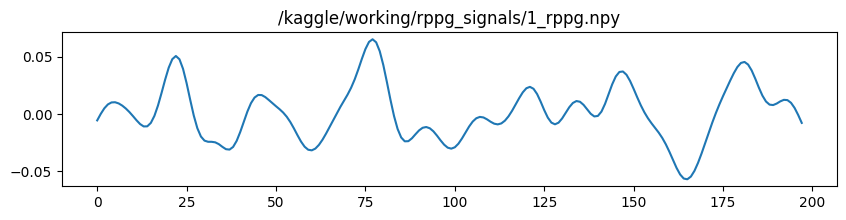

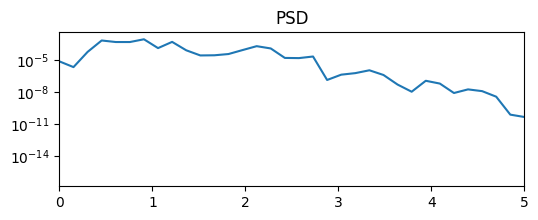

In [7]:
######Sanity check

import numpy as np, glob
from scipy.signal import welch
sig_files = sorted(glob.glob('/kaggle/working/rppg_signals/*_rppg.npy'))
print('Found signals:', len(sig_files))
if len(sig_files) > 0:
    s = np.load(sig_files[0])
    print('Signal len:', len(s))
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,2)); plt.plot(s); plt.title(sig_files[0]); plt.show()
    f,P = welch(s, fs=30.0, nperseg=min(256,len(s)))
    plt.figure(figsize=(6,2)); plt.semilogy(f,P); plt.xlim(0,5); plt.title('PSD'); plt.show()
else:
    print('No saved rPPG signals found — check previous cell output for errors.')


In [8]:
# ------------------------------
# Cell 5: Feature extraction from rPPG signals
# ------------------------------
# Compute per-video features: peak BPM, HRV proxy (std), spectral entropy, periodicity strength

from scipy.signal import welch


def features_from_rppg(sig, fs=FS):
    sig = sig - np.mean(sig)
    # PSD
    f, Pxx = welch(sig, fs=fs, nperseg=min(256, len(sig)))
    # restrict HR band (0.7-3.5 Hz -> 42-210 bpm)
    hr_band = (f >= 0.7) & (f <= 3.5)
    if hr_band.sum() == 0:
        peak_bpm = 0.0
        entropy = 0.0
        peak_power = 0.0
    else:
        idx = np.argmax(Pxx[hr_band])
        peak_freq = f[hr_band][idx]
        peak_bpm = peak_freq * 60.0
        Pnorm = Pxx[hr_band] / (np.sum(Pxx[hr_band]) + 1e-12)
        entropy = -np.sum(Pnorm * np.log(Pnorm + 1e-12))
        peak_power = np.max(Pxx[hr_band])
    # time domain features
    std = np.std(sig)
    acorr = np.correlate(sig, sig, mode='full')
    acorr = acorr[acorr.size//2:]
    periodicity = np.max(acorr) / (acorr[0] + 1e-12)
    return {
        'peak_bpm': float(peak_bpm),
        'spec_entropy': float(entropy),
        'peak_power': float(peak_power),
        'std': float(std),
        'periodicity': float(periodicity)
    }

# apply on meta_df
feat_rows = []
for _, r in meta_df.iterrows():
    sig = np.load(r['rppg_path'])
    feats = features_from_rppg(sig)
    feats.update({'video': r['video'], 'path': r['path'], 'label': r['label']})
    feat_rows.append(feats)

feat_df = pd.DataFrame(feat_rows)
feat_df.to_csv(os.path.join(RPPG_OUTPUT_DIR, 'features.csv'), index=False)
feat_df.head()

,peak_bpm,spec_entropy,peak_power,std,periodicity,video,path,label
0,54.545455,1.967175,0.000815,0.024264,1.0,1,/kaggle/input/deepfake-videos-dataset/deepfake...,1
1,70.312500,2.104101,0.000004,0.005533,1.0,2,/kaggle/input/deepfake-videos-dataset/deepfake...,1
2,49.218750,2.007798,0.000186,0.012713,1.0,3,/kaggle/input/deepfake-videos-dataset/deepfake...,1
3,50.000000,1.610485,0.000176,0.009625,1.0,4,/kaggle/input/deepfake-videos-dataset/deepfake...,1
4,42.187500,2.301200,0.000030,0.004741,1.0,5,/kaggle/input/deepfake-videos-dataset/deepfake...,1


In [9]:
# ------------------------------
# Cell 6: Train/test split and classifier
# ------------------------------
# We'll use labels inferred from folder names (deepfake -> 1, video -> 0). If you have a CSV with labels
# you can merge them here (e.g., the dataset provided contains DeepFake Videos Dataset.csv)

# Try to read provided CSV and merge labels if present
csv_path = os.path.join(DATASET_ROOT, 'DeepFake Videos Dataset.csv')
if os.path.exists(csv_path):
    try:
        df_csv = pd.read_csv(csv_path)
        print('Found CSV with', len(df_csv), 'rows. Attempting to merge labels (if present).')
        # Attempt to find columns: filename and label-like column
        # This is heuristic; you may need to adapt depending on CSV structure
        # For now we'll simply print columns for inspection
        print(df_csv.columns)
    except Exception as e:
        print('Failed reading CSV:', e)

# Prepare X, y
X = feat_df[['peak_bpm','spec_entropy','peak_power','std','periodicity']].fillna(0).values
y = feat_df['label'].values

if len(np.unique(y)) < 2:
    print('Warning: only one class detected in labels. Check folder structure and CSV labels.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if len(np.unique(y))>1 else None)

Found CSV with 5 rows. Attempting to merge labels (if present).
Index(['id', 'deepfake', 'image', 'video'], dtype='object')


In [10]:
# ------------------------------
# Cell 7: Train a Random Forest classifier and evaluate
# ------------------------------
clf = RandomForestClassifier(n_estimators=200, random_state=42)
if len(np.unique(y_train))>1:
    clf.fit(X_train, y_train)
    # predictions
    y_prob = clf.predict_proba(X_test)[:,1] if hasattr(clf, 'predict_proba') else clf.predict(X_test)
    if len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_prob)
        print('Test AUC:', auc)

    y_pred = (y_prob > 0.5).astype(int)
    print(classification_report(y_test, y_pred))
    joblib.dump(clf, '/kaggle/working/rppg_rf_model.joblib')
    print('Saved model to /kaggle/working/rppg_rf_model.joblib')
else:
    print('Not enough classes to train classifier. Labels:', np.unique(y_train))

Test AUC: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0

Saved model to /kaggle/working/rppg_rf_model.joblib


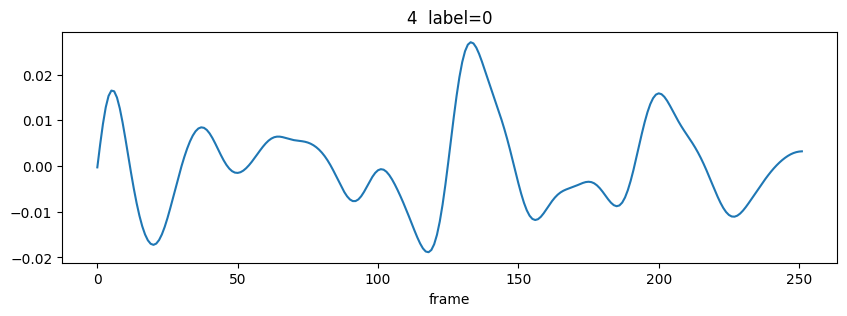

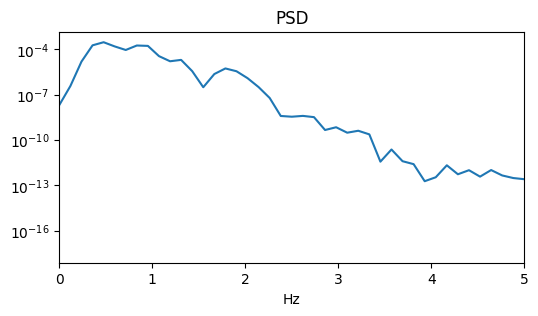

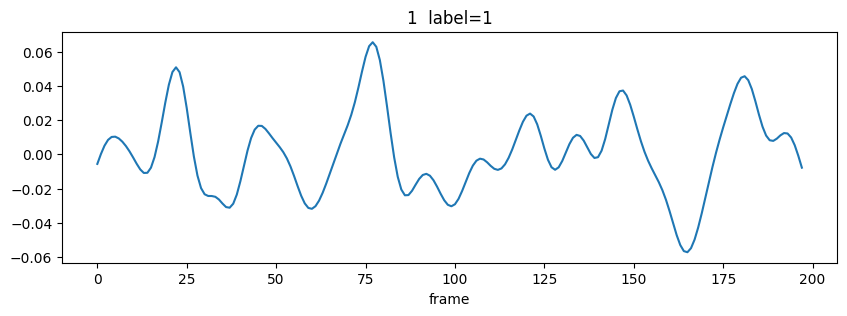

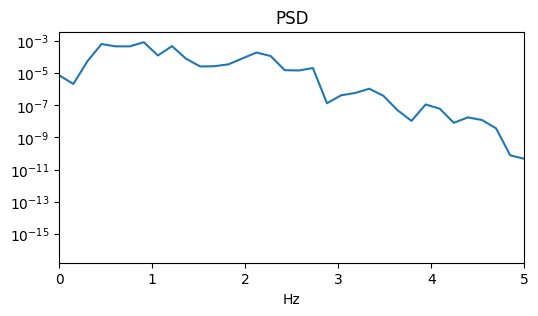

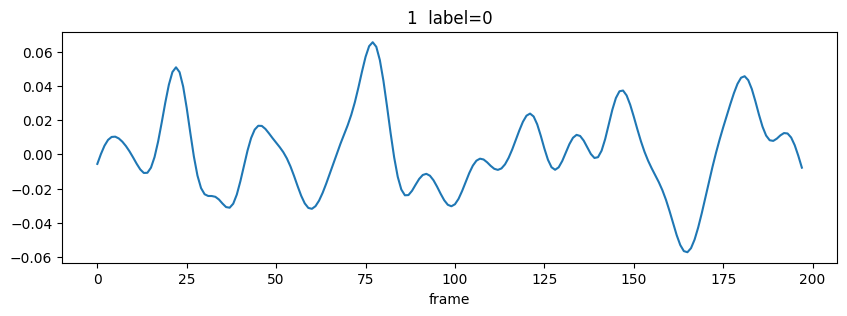

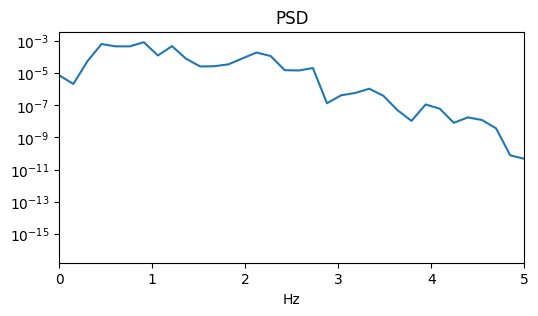

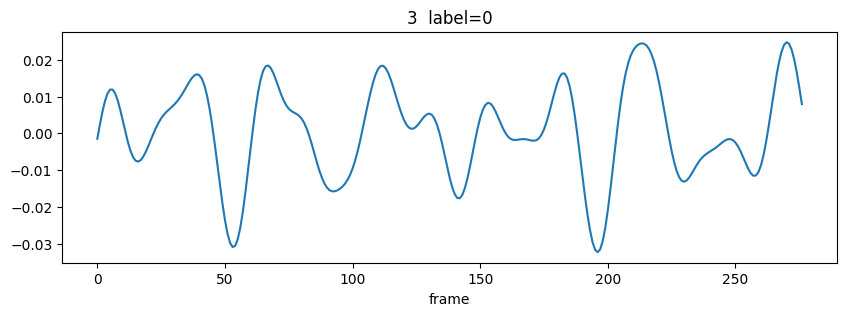

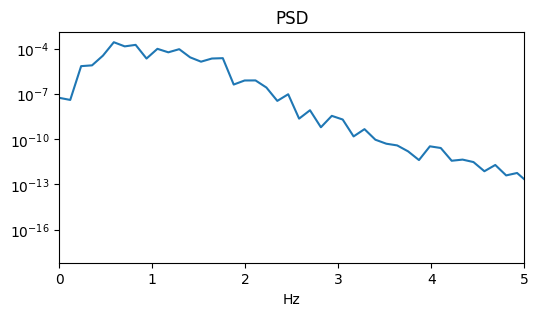

In [11]:
# ------------------------------
# Cell 8: Quick visualization — sample rPPG traces and PSDs
# ------------------------------
for i, row in feat_df.sample(min(4, len(feat_df))).iterrows():
    sig = np.load(os.path.join(RPPG_OUTPUT_DIR, row['video'] + '_rppg.npy'))
    plt.figure(figsize=(10,3))
    plt.plot(sig)
    plt.title(f"{row['video']}  label={row['label']}")
    plt.xlabel('frame')
    plt.show()
    # PSD
    f, Pxx = welch(sig, fs=FS, nperseg=min(256, len(sig)))
    plt.figure(figsize=(6,3))
    plt.semilogy(f, Pxx)
    plt.xlim(0, 5)
    plt.xlabel('Hz')
    plt.title('PSD')
    plt.show()

In [12]:
# ------------------------------
# Cell 9: Next steps & enhancements (text cell for notebook)
# ------------------------------
# - Use the rPPG-Toolbox's advanced extractors (POS, ICA, deep models) for better signals.
# - Use larger labeled training datasets (FaceForensics++ or DFDC samples) for a proper benchmark.
# - Combine rPPG features with spatial CNN features (frame-level embeddings) for ensemble performance.
# - Add data augmentation (recompression, cropping, motion) to make the detector robust.

print('Prototype skeleton complete. Tweak paths, labels, and extraction params as needed.')

Prototype skeleton complete. Tweak paths, labels, and extraction params as needed.


In [13]:
# show features + labels
print("Features dataframe shape:", feat_df.shape)
display(feat_df)

# show meta (video, fps, rppg_path)
print("Meta df:")
display(meta_df)

# class distribution
print("Label counts (meta_df):")
print(meta_df['label'].value_counts())
print("Label counts (feat_df):")
print(feat_df['label'].value_counts(dropna=False))


Features dataframe shape: (10, 8)


,peak_bpm,spec_entropy,peak_power,std,periodicity,video,path,label
0,54.545455,1.967175,0.000815,0.024264,1.0,1,/kaggle/input/deepfake-videos-dataset/deepfake...,1
1,70.312500,2.104101,0.000004,0.005533,1.0,2,/kaggle/input/deepfake-videos-dataset/deepfake...,1
2,49.218750,2.007798,0.000186,0.012713,1.0,3,/kaggle/input/deepfake-videos-dataset/deepfake...,1
3,50.000000,1.610485,0.000176,0.009625,1.0,4,/kaggle/input/deepfake-videos-dataset/deepfake...,1
4,42.187500,2.301200,0.000030,0.004741,1.0,5,/kaggle/input/deepfake-videos-dataset/deepfake...,1
5,54.545455,1.967175,0.000815,0.024264,1.0,1,/kaggle/input/deepfake-videos-dataset/video/1.mp4,0
6,70.312500,2.104101,0.000004,0.005533,1.0,2,/kaggle/input/deepfake-videos-dataset/video/2.mp4,0
7,49.218750,2.007798,0.000186,0.012713,1.0,3,/kaggle/input/deepfake-videos-dataset/video/3.mp4,0
8,50.000000,1.610485,0.000176,0.009625,1.0,4,/kaggle/input/deepfake-videos-dataset/video/4.mp4,0
9,42.187500,2.301200,0.000030,0.004741,1.0,5,/kaggle/input/deepfake-videos-dataset/video/5.MOV,0


Meta df:


,video,path,rppg_path,frames,fps,label
0,1,/kaggle/input/deepfake-videos-dataset/deepfake...,/kaggle/working/rppg_signals/1_rppg.npy,200,20.000000,1
1,2,/kaggle/input/deepfake-videos-dataset/deepfake...,/kaggle/working/rppg_signals/2_rppg.npy,135,30.000000,1
2,3,/kaggle/input/deepfake-videos-dataset/deepfake...,/kaggle/working/rppg_signals/3_rppg.npy,221,24.000000,1
3,4,/kaggle/input/deepfake-videos-dataset/deepfake...,/kaggle/working/rppg_signals/4_rppg.npy,202,24.000000,1
4,5,/kaggle/input/deepfake-videos-dataset/deepfake...,/kaggle/working/rppg_signals/5_rppg.npy,241,24.000000,1
5,1,/kaggle/input/deepfake-videos-dataset/video/1.mp4,/kaggle/working/rppg_signals/1_rppg.npy,198,20.001055,0
6,2,/kaggle/input/deepfake-videos-dataset/video/2.mp4,/kaggle/working/rppg_signals/2_rppg.npy,324,29.993705,0
7,3,/kaggle/input/deepfake-videos-dataset/video/3.mp4,/kaggle/working/rppg_signals/3_rppg.npy,277,30.121210,0
8,4,/kaggle/input/deepfake-videos-dataset/video/4.mp4,/kaggle/working/rppg_signals/4_rppg.npy,252,30.011314,0
9,5,/kaggle/input/deepfake-videos-dataset/video/5.MOV,/kaggle/working/rppg_signals/5_rppg.npy,358,24.002682,0


Label counts (meta_df):
label
1    5
0    5
Name: count, dtype: int64
Label counts (feat_df):
label
1    5
0    5
Name: count, dtype: int64


In [14]:
# recreate the split exactly as your cell did, and print details
required = ['peak_bpm','spec_entropy','peak_power','std','periodicity']
X = feat_df[required].fillna(0).values
y = feat_df['label'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
    stratify=y if len(np.unique(y))>1 else None)

print("X_train.shape, X_test.shape:", X_train.shape, X_test.shape)
print("y_train counts:", {c:int((y_train==c).sum()) for c in np.unique(y_train)})
print("y_test counts:", {c:int((y_test==c).sum()) for c in np.unique(y_test)})

# load model if saved or re-train quick
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# predictions + probs
if hasattr(clf, 'predict_proba'):
    y_prob = clf.predict_proba(X_test)[:,1]
else:
    y_prob = clf.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print("y_test:", y_test)
print("y_prob:", np.round(y_prob,3))
print("y_pred:", y_pred)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
if len(np.unique(y_test))>1:
    print("AUC:", roc_auc_score(y_test, y_prob))
else:
    print("Only one class in test set — AUC not defined.")


X_train.shape, X_test.shape: (7, 5) (3, 5)
y_train counts: {0: 3, 1: 4}
y_test counts: {0: 2, 1: 1}
y_test: [0 0 1]
y_prob: [0.898 0.849 0.175]
y_pred: [1 1 0]
Confusion matrix:
 [[0 2]
 [1 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0

AUC: 0.0


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=min(4, max(2, len(y))))  # small data -> small folds
clf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc', error_score='raise')
print("CV AUC scores:", scores, "mean:", np.nanmean(scores))


CV AUC scores: [0.25 0.25 0.5  0.5 ] mean: 0.375


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = feat_df[['peak_bpm','spec_entropy','peak_power','std','periodicity']].fillna(0).values
y = feat_df['label'].values

cv = StratifiedKFold(n_splits=min(5, len(y)))  # auto-adjust for small set
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
print("Cross-val AUC scores:", np.round(scores,3))
print("Mean AUC:", np.mean(scores))


Cross-val AUC scores: [0.5 0.5 0.5 0.5 0.5]
Mean AUC: 0.5


In [17]:
# Requires: the notebook functions extract_roi_mean_colors() and chrom_method(),
# and the feature extractor features_from_rppg() from your pipeline.
# Also requires joblib (sklearn) and OpenCV.

import joblib
import numpy as np
import os

# load model (path to your saved model)
MODEL_PATH = '/kaggle/working/rppg_rf_model.joblib'  # change if needed
if os.path.exists(MODEL_PATH):
    clf = joblib.load(MODEL_PATH)
    print("Loaded model:", MODEL_PATH)
else:
    clf = None
    print("Model not found at", MODEL_PATH, "- inference will fail until you train/save a model.")

def compute_features_from_video(video_path, max_frames=800, resize_width=480):
    # returns feature vector (ordered the same as training) and meta dict
    rgb, fps = extract_roi_mean_colors(video_path, max_frames=max_frames, resize_width=resize_width)
    if rgb is None:
        raise ValueError("No face/ROI found in video: " + video_path)
    sig = chrom_method(rgb, fs=fps if fps>0 else 30.0)
    feats = features_from_rppg(sig, fs=fps if fps>0 else 30.0)  # returns dict with keys used during training
    # order features in same order as training
    order = ['peak_bpm','spec_entropy','peak_power','std','periodicity']
    X = np.array([feats[k] for k in order], dtype=float).reshape(1, -1)
    meta = {'fps': fps, 'frames': rgb.shape[0], 'raw_features': feats}
    return X, meta

def predict_video_rppg(video_path, model=clf, threshold=0.5):
    if model is None:
        raise ValueError("No model provided. Train or load a model first.")
    X, meta = compute_features_from_video(video_path)
    # optional: scaling if you used a scaler during training. If yes, load it and apply.
    # scaler = joblib.load('/kaggle/working/scaler.joblib')  # if you saved one
    # X = scaler.transform(X)
    if hasattr(model, 'predict_proba'):
        prob_fake = float(model.predict_proba(X)[0,1])
    else:
        # fallback: model predicts labels only
        pred = int(model.predict(X)[0])
        prob_fake = float(pred)
    label = 1 if prob_fake >= threshold else 0
    return {'prob_fake': prob_fake, 'label': int(label), 'meta': meta}

# Example usage:
video_test = '/kaggle/input/deepfake-videos-dataset/video/1.mp4'
res = predict_video_rppg(video_test)
print("prob_fake:", res['prob_fake'], "label:", res['label'])
print("meta:", res['meta'])


Loaded model: /kaggle/working/rppg_rf_model.joblib


/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


prob_fake: 0.7719166666666665 label: 1
meta: {'fps': 20.00105505004192, 'frames': 198, 'raw_features': {'peak_bpm': 48.4874061819198, 'spec_entropy': 1.9439921159616547, 'peak_power': 0.0006982575517323362, 'std': 0.02426350092747099, 'periodicity': 0.9999999999914211}}
